# Phase 5 — Real Image Processing

## Objective

The goal of this phase is to prepare the face recognition pipeline for real-world photographs.

The system should be able to:

- Accept a real input photograph
- Detect one or more faces
- Handle different face conditions
- Extract the detected face region
- Generate an ArcFace face embedding
- Prepare the image for one-to-many missing-person search

In this phase, different face detection approaches will be evaluated before selecting the detector for the final application.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from deepface import DeepFace

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load input photograph

IMAGE_PATH = "photo1.jpg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

print("Image loaded successfully!")
print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (413, 413, 3)


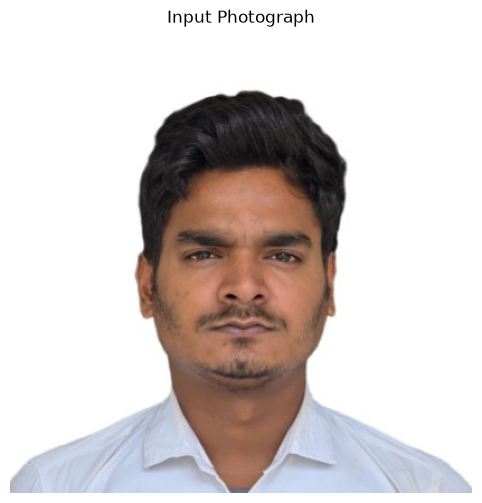

In [3]:
# Display input photograph

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input Photograph")
plt.show()

In [4]:
# Test MTCNN face detection

detections = DeepFace.extract_faces(
    img_path=image,
    detector_backend="mtcnn",
    enforce_detection=False,
    align=True
)

print("Number of detected faces:", len(detections))

for i, face in enumerate(detections):
    print(f"Face {i + 1}:")
    print("  Confidence:", face["confidence"])
    print("  Face shape:", face["face"].shape)

Number of detected faces: 1
Face 1:
  Confidence: 1.0
  Face shape: (194, 150, 3)


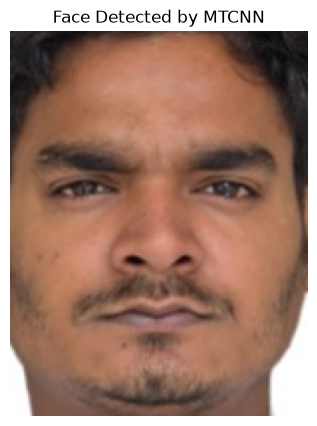

In [5]:
# Visualize the face detected by MTCNN

detected_face = detections[0]["face"]

plt.figure(figsize=(5, 5))
plt.imshow(detected_face)
plt.axis("off")
plt.title("Face Detected by MTCNN")
plt.show()

In [6]:
# Generate ArcFace embedding from the MTCNN-detected face

embedding_result = DeepFace.represent(
    img_path=detected_face,
    model_name="ArcFace",
    detector_backend="skip",
    enforce_detection=False
)

embedding = np.array(embedding_result[0]["embedding"])

print("Embedding generated successfully!")
print("Embedding shape:", embedding.shape)

Embedding generated successfully!
Embedding shape: (512,)


## Comparing Face Detectors

The current prototype used OpenCV Haar Cascade for face detection.

In this phase, MTCNN is being evaluated as an alternative face detector.

The goal is to compare the quality of the detected face regions before selecting
the detector for the final Missing Person Finder pipeline.

In [7]:
# Test OpenCV Haar Cascade face detection

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Number of detected faces:", len(faces))

for i, (x, y, w, h) in enumerate(faces):
    print(f"Face {i + 1}:")
    print("  Position:", (x, y))
    print("  Size:", (w, h))

Number of detected faces: 1
Face 1:
  Position: (np.int32(114), np.int32(125))
  Size: (np.int32(190), np.int32(190))


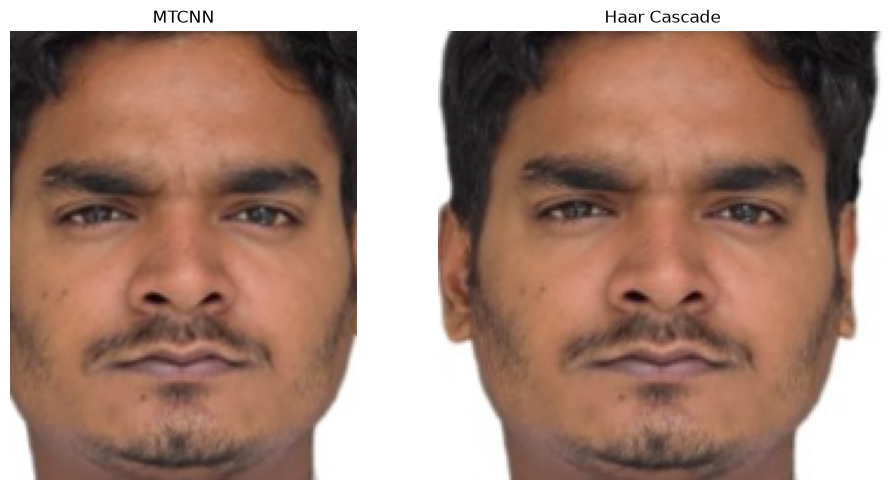

In [8]:
# Compare MTCNN and Haar Cascade face regions

x, y, w, h = faces[0]

haar_face = image_rgb[y:y+h, x:x+w]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(detected_face)
plt.axis("off")
plt.title("MTCNN")

plt.subplot(1, 2, 2)
plt.imshow(haar_face)
plt.axis("off")
plt.title("Haar Cascade")

plt.tight_layout()
plt.show()

## MTCNN Detection Test on Multiple Images

A face detector should not be selected based on a single image.

We will test MTCNN on multiple photographs and check whether it can
consistently detect the expected face regions.

In [9]:
# Test MTCNN on multiple photographs

test_images = [
    "deepface_repo/tests/unit/dataset/img1.jpg",
    "deepface_repo/tests/unit/dataset/img3.jpg",
    "deepface_repo/tests/unit/dataset/img13.jpg",
    "deepface_repo/tests/unit/dataset/img16.jpg",
    "deepface_repo/tests/unit/dataset/img18.jpg",
    "deepface_repo/tests/unit/dataset/img20.jpg",
    "deepface_repo/tests/unit/dataset/img22.jpg",
    "deepface_repo/tests/unit/dataset/img24.jpg"
]

for image_path in test_images:
    detections = DeepFace.extract_faces(
        img_path=image_path,
        detector_backend="mtcnn",
        enforce_detection=False,
        align=True
    )

    print(
        os.path.basename(image_path),
        "→",
        len(detections),
        "face(s)"
    )

img1.jpg → 1 face(s)
img3.jpg → 1 face(s)
img13.jpg → 1 face(s)
img16.jpg → 1 face(s)
img18.jpg → 1 face(s)
img20.jpg → 1 face(s)
img22.jpg → 1 face(s)
img24.jpg → 1 face(s)


## MTCNN Detection Results

MTCNN was tested on 8 photographs from the evaluation dataset.

### Results

- Images tested: 8
- Images with exactly one detected face: 8
- Images with no detected face: 0
- Images with multiple detected faces: 0
- Detection success rate: 100%

### Observation

MTCNN successfully detected exactly one face in all 8 tested photographs.

This provides an initial indication that MTCNN is suitable for the current
prototype images. However, this result is based on a small and controlled
sample and should not be interpreted as real-world detection accuracy.

Further testing with varied real-world photographs is required before
finalizing the face detector.

In [11]:
# Cosine distance function

def cosine_distance(embedding_a, embedding_b):
    similarity = np.dot(embedding_a, embedding_b) / (
        np.linalg.norm(embedding_a) * np.linalg.norm(embedding_b)
    )

    distance = 1 - similarity

    return distance

print("Cosine distance function ready!")

Cosine distance function ready!


In [12]:
# Test the complete MTCNN + ArcFace search pipeline

# Load stored face embeddings
saved_data = np.load("face_embeddings.npz")

stored_embeddings = saved_data["embeddings"]
stored_metadata = saved_data["metadata"]

# Detect face using MTCNN
query_path = "deepface_repo/tests/unit/dataset/img1.jpg"

mtcnn_faces = DeepFace.extract_faces(
    img_path=query_path,
    detector_backend="mtcnn",
    enforce_detection=True,
    align=True
)

query_face = mtcnn_faces[0]["face"]

# Generate ArcFace embedding from the MTCNN face crop
result = DeepFace.represent(
    img_path=query_face,
    model_name="ArcFace",
    detector_backend="skip",
    enforce_detection=False
)

query_embedding = np.array(result[0]["embedding"])

print("Query embedding shape:", query_embedding.shape)

# Calculate distances against stored embeddings
search_results = []

for i, stored_embedding in enumerate(stored_embeddings):

    distance = cosine_distance(
        query_embedding,
        stored_embedding
    )

    search_results.append({
        "person": stored_metadata[i][0],
        "image": stored_metadata[i][1],
        "distance": distance
    })

# Rank by smallest distance
search_results = sorted(
    search_results,
    key=lambda x: x["distance"]
)

print("\nTop 5 matches:")

for result in search_results[:5]:
    print(
        result["person"],
        result["image"],
        "distance:",
        round(result["distance"], 4)
    )

Query embedding shape: (512,)

Top 5 matches:
person1 img5.jpg distance: 0.5624
person1 img4.jpg distance: 0.593
person1 img7.jpg distance: 0.5941
person1 img2.jpg distance: 0.5975
person1 img11.jpg distance: 0.6292


In [13]:
# Evaluate MTCNN + ArcFace search on all 8 identities

test_queries = [
    ("person1", "img1.jpg"),
    ("person2", "img3.jpg"),
    ("person3", "img13.jpg"),
    ("person4", "img16.jpg"),
    ("person5", "img18.jpg"),
    ("person6", "img20.jpg"),
    ("person7", "img22.jpg"),
    ("person8", "img24.jpg")
]

dataset_dir = "deepface_repo/tests/unit/dataset"

for expected_person, image_name in test_queries:

    query_path = os.path.join(dataset_dir, image_name)

    # Detect face using MTCNN
    mtcnn_faces = DeepFace.extract_faces(
        img_path=query_path,
        detector_backend="mtcnn",
        enforce_detection=True,
        align=True
    )

    query_face = mtcnn_faces[0]["face"]

    # Generate ArcFace embedding
    result = DeepFace.represent(
        img_path=query_face,
        model_name="ArcFace",
        detector_backend="skip",
        enforce_detection=False
    )

    query_embedding = np.array(result[0]["embedding"])

    # Search stored embeddings
    search_results = []

    for i, stored_embedding in enumerate(stored_embeddings):

        # Exclude the query image itself
        if stored_metadata[i][1] == image_name:
            continue

        distance = cosine_distance(
            query_embedding,
            stored_embedding
        )

        search_results.append({
            "person": stored_metadata[i][0],
            "image": stored_metadata[i][1],
            "distance": distance
        })

    # Rank by smallest distance
    search_results.sort(key=lambda x: x["distance"])

    top_match = search_results[0]

    correct = top_match["person"] == expected_person

    print(
        f"{image_name} | Expected: {expected_person} | "
        f"Predicted: {top_match['person']} | "
        f"Distance: {top_match['distance']:.4f} | "
        f"Correct: {correct}"
    )

img1.jpg | Expected: person1 | Predicted: person1 | Distance: 0.5624 | Correct: True
img3.jpg | Expected: person2 | Predicted: person2 | Distance: 0.5680 | Correct: True
img13.jpg | Expected: person3 | Predicted: person3 | Distance: 0.2463 | Correct: True
img16.jpg | Expected: person4 | Predicted: person4 | Distance: 0.2689 | Correct: True
img18.jpg | Expected: person5 | Predicted: person5 | Distance: 0.1892 | Correct: True
img20.jpg | Expected: person6 | Predicted: person6 | Distance: 0.3305 | Correct: True
img22.jpg | Expected: person7 | Predicted: person7 | Distance: 0.4230 | Correct: True
img24.jpg | Expected: person8 | Predicted: person8 | Distance: 0.4694 | Correct: True


## MTCNN + ArcFace Evaluation

The complete MTCNN-based face search pipeline was evaluated using 8 held-out
queries representing 8 different identities.

### Results

- Queries tested: 8
- Correct Top-1 predictions: 8
- Incorrect Top-1 predictions: 0
- Top-1 accuracy: 100%

All 8 queries were correctly ranked with the expected identity as the
Top-1 result.

The largest correct-match cosine distance was 0.5680, which remained below
the prototype threshold of 0.68.

### Observation

MTCNN successfully detected one face in all 8 test photographs, and the
complete MTCNN → ArcFace → one-to-many search pipeline correctly identified
all 8 evaluation queries.

However, these results are based on a small controlled evaluation set and
should not be interpreted as real-world recognition accuracy.

Further comparison with the existing Haar Cascade pipeline is required
before selecting the final face detector.

In [16]:
import pandas as pd

print("Pandas imported successfully!")

Pandas imported successfully!


In [17]:
# Compare Haar Cascade and MTCNN

comparison_results = []

for expected_person, image_name in test_queries:

    query_path = os.path.join(dataset_dir, image_name)

    # --------------------------------------------------
    # 1. Haar Cascade
    # --------------------------------------------------

    original_image = cv2.imread(query_path)
    gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) > 0:

        x, y, w, h = faces[0]
        haar_face = original_image[y:y+h, x:x+w]

        haar_result = DeepFace.represent(
            img_path=haar_face,
            model_name="ArcFace",
            detector_backend="skip",
            enforce_detection=False
        )

        haar_embedding = np.array(
            haar_result[0]["embedding"]
        )

        haar_search = []

        for i, stored_embedding in enumerate(stored_embeddings):

            if stored_metadata[i][1] == image_name:
                continue

            distance = cosine_distance(
                haar_embedding,
                stored_embedding
            )

            haar_search.append(
                (stored_metadata[i][0], distance)
            )

        haar_search.sort(key=lambda x: x[1])

        haar_person = haar_search[0][0]
        haar_distance = haar_search[0][1]

    else:
        haar_person = "No face"
        haar_distance = None


    # --------------------------------------------------
    # 2. MTCNN
    # --------------------------------------------------

    mtcnn_faces = DeepFace.extract_faces(
        img_path=query_path,
        detector_backend="mtcnn",
        enforce_detection=True,
        align=True
    )

    mtcnn_face = mtcnn_faces[0]["face"]

    mtcnn_result = DeepFace.represent(
        img_path=mtcnn_face,
        model_name="ArcFace",
        detector_backend="skip",
        enforce_detection=False
    )

    mtcnn_embedding = np.array(
        mtcnn_result[0]["embedding"]
    )

    mtcnn_search = []

    for i, stored_embedding in enumerate(stored_embeddings):

        if stored_metadata[i][1] == image_name:
            continue

        distance = cosine_distance(
            mtcnn_embedding,
            stored_embedding
        )

        mtcnn_search.append(
            (stored_metadata[i][0], distance)
        )

    mtcnn_search.sort(key=lambda x: x[1])

    mtcnn_person = mtcnn_search[0][0]
    mtcnn_distance = mtcnn_search[0][1]


    # Store result
    comparison_results.append({
        "query": image_name,
        "expected": expected_person,
        "haar_prediction": haar_person,
        "haar_distance": haar_distance,
        "mtcnn_prediction": mtcnn_person,
        "mtcnn_distance": mtcnn_distance
    })


# Display results
comparison_df = pd.DataFrame(comparison_results)

comparison_df

,query,expected,haar_prediction,haar_distance,mtcnn_prediction,mtcnn_distance
0,img1.jpg,person1,person1,0.490082,person1,0.562369
1,img3.jpg,person2,person2,0.654518,person2,0.567986
2,img13.jpg,person3,person3,0.244870,person3,0.246294
3,img16.jpg,person4,person4,0.241889,person4,0.268853
4,img18.jpg,person5,person5,0.222858,person5,0.189202
5,img20.jpg,person6,person3,0.926004,person6,0.330500
6,img22.jpg,person7,person3,0.917115,person7,0.423014
7,img24.jpg,person8,person8,0.506010,person8,0.469393


In [18]:
# Calculate detector comparison metrics

haar_correct = (
    comparison_df["haar_prediction"]
    == comparison_df["expected"]
).sum()

mtcnn_correct = (
    comparison_df["mtcnn_prediction"]
    == comparison_df["expected"]
).sum()

total_queries = len(comparison_df)

haar_accuracy = haar_correct / total_queries * 100
mtcnn_accuracy = mtcnn_correct / total_queries * 100

print("Detector Comparison")
print("--------------------")

print(
    f"Haar Cascade: {haar_correct}/{total_queries} "
    f"correct ({haar_accuracy:.2f}%)"
)

print(
    f"MTCNN:        {mtcnn_correct}/{total_queries} "
    f"correct ({mtcnn_accuracy:.2f}%)"
)

Detector Comparison
--------------------
Haar Cascade: 6/8 correct (75.00%)
MTCNN:        8/8 correct (100.00%)


## Face Detector Comparison

The existing Haar Cascade detector was compared with MTCNN using the same
8 held-out query images and the same ArcFace recognition pipeline.

### Results

| Detector | Correct Predictions | Top-1 Accuracy |
|---|---:|---:|
| Haar Cascade | 6 / 8 | 75.00% |
| MTCNN | 8 / 8 | 100.00% |

### Observation

Both detectors successfully detected faces in the tested photographs.
However, the recognition results differed after the detected face regions
were passed to ArcFace.

Haar Cascade correctly identified 6 out of 8 queries, while MTCNN correctly
identified all 8 queries.

### Decision

Based on this controlled experiment, **MTCNN is selected as the face detector
for the next stage of the prototype**.

This result should not be interpreted as general or real-world accuracy because
the evaluation contains only 8 controlled queries. Further testing with
real-world photographs and more varied conditions is required.

The ArcFace model remains responsible for generating the 512-dimensional face
embeddings and performing face representation.

In [19]:
# Create a controlled multiple-face test image

img_a = cv2.imread(
    "deepface_repo/tests/unit/dataset/img1.jpg"
)

img_b = cv2.imread(
    "deepface_repo/tests/unit/dataset/img13.jpg"
)

# Resize both images to the same height
height = 400

width_a = int(img_a.shape[1] * height / img_a.shape[0])
width_b = int(img_b.shape[1] * height / img_b.shape[0])

img_a = cv2.resize(img_a, (width_a, height))
img_b = cv2.resize(img_b, (width_b, height))

# Place the two faces side by side
multiple_face_image = np.hstack((img_a, img_b))

# Save the test image
MULTIPLE_FACE_PATH = "test_multiple_faces.jpg"

cv2.imwrite(
    MULTIPLE_FACE_PATH,
    multiple_face_image
)

print("Multiple-face test image created!")
print("Path:", MULTIPLE_FACE_PATH)
print("Image shape:", multiple_face_image.shape)

Multiple-face test image created!
Path: test_multiple_faces.jpg
Image shape: (400, 895, 3)


In [20]:
# Detect multiple faces using MTCNN

multiple_detections = DeepFace.extract_faces(
    img_path=MULTIPLE_FACE_PATH,
    detector_backend="mtcnn",
    enforce_detection=True,
    align=True
)

print("Number of detected faces:", len(multiple_detections))

for i, face in enumerate(multiple_detections):
    print(
        f"Face {i + 1}: "
        f"confidence = {face['confidence']:.4f}, "
        f"shape = {face['face'].shape}"
    )

Number of detected faces: 2
Face 1: confidence = 1.0000, shape = (175, 118, 3)
Face 2: confidence = 0.9800, shape = (168, 115, 3)


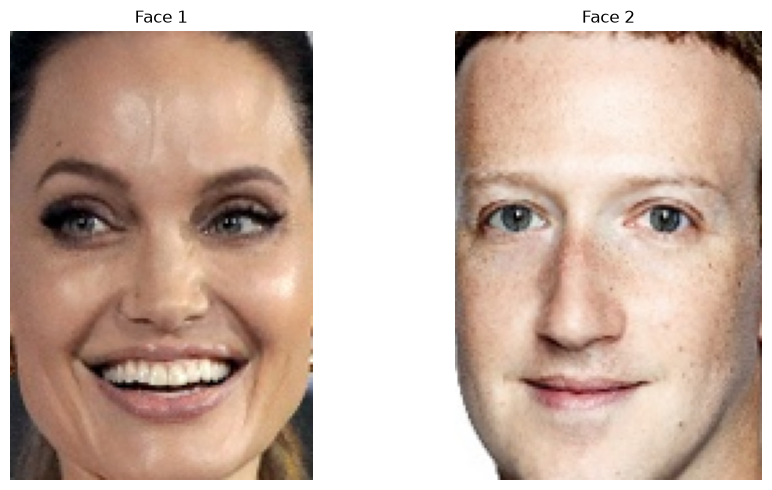

In [21]:
# Visualize all detected faces

plt.figure(figsize=(10, 5))

for i, detection in enumerate(multiple_detections):
    plt.subplot(1, len(multiple_detections), i + 1)
    
    plt.imshow(detection["face"])
    plt.axis("off")
    plt.title(f"Face {i + 1}")

plt.tight_layout()
plt.show()

In [28]:
# Handle different numbers of detected faces safely

def handle_detected_faces(detections):

    # Remove fallback results that have zero confidence
    valid_faces = [
        detection
        for detection in detections
        if detection["confidence"] > 0
    ]

    face_count = len(valid_faces)

    if face_count == 0:
        return "NO_FACE"

    elif face_count == 1:
        return "SINGLE_FACE"

    else:
        return "MULTIPLE_FACES"


print("Face handling function updated!")

Face handling function updated!


In [29]:
# Test single-face case

single_face_detections = DeepFace.extract_faces(
    img_path="deepface_repo/tests/unit/dataset/img1.jpg",
    detector_backend="mtcnn",
    enforce_detection=False,
    align=True
)

single_result = handle_detected_faces(single_face_detections)

print("Detection result:", single_result)
print("Number of faces:", len(single_face_detections))

Detection result: SINGLE_FACE
Number of faces: 1


In [30]:
# Create a test image containing no face

no_face_image = np.zeros((400, 400, 3), dtype=np.uint8)

NO_FACE_PATH = "test_no_face.jpg"

cv2.imwrite(NO_FACE_PATH, no_face_image)

print("No-face test image created!")

No-face test image created!


In [31]:
# Test MTCNN on an image with no face

no_face_detections = DeepFace.extract_faces(
    img_path=NO_FACE_PATH,
    detector_backend="mtcnn",
    enforce_detection=False,
    align=True
)

print("Number of detected faces:", len(no_face_detections))

no_face_result = handle_detected_faces(no_face_detections)

print("Detection result:", no_face_result)

Number of detected faces: 1
Detection result: NO_FACE


In [27]:
# Inspect the detection returned for the blank image

for i, detection in enumerate(no_face_detections):

    print(f"Face {i + 1}")
    print("Confidence:", detection["confidence"])
    print("Face shape:", detection["face"].shape)

Face 1
Confidence: 0.0
Face shape: (400, 400, 3)


In [32]:
# Re-test the no-face case

no_face_result = handle_detected_faces(no_face_detections)

print("Detection result:", no_face_result)

Detection result: NO_FACE


In [33]:
# Reusable MTCNN face detection function

def detect_faces(image_path):
    
    detections = DeepFace.extract_faces(
        img_path=image_path,
        detector_backend="mtcnn",
        enforce_detection=False,
        align=True
    )

    # Remove fallback results with zero confidence
    valid_faces = [
        detection
        for detection in detections
        if detection["confidence"] > 0
    ]

    return valid_faces


print("Face detection function ready!")

Face detection function ready!


In [34]:
# Test reusable face detection function

faces = detect_faces(
    "deepface_repo/tests/unit/dataset/img1.jpg"
)

print("Detected valid faces:", len(faces))

Detected valid faces: 1


In [35]:
# Test multiple-face detection

faces = detect_faces(
    MULTIPLE_FACE_PATH
)

print("Detected valid faces:", len(faces))

Detected valid faces: 2


In [36]:
# Test no-face detection

faces = detect_faces(
    NO_FACE_PATH
)

print("Detected valid faces:", len(faces))

Detected valid faces: 0


In [37]:
def generate_face_embeddings(image_path):
    
    faces = detect_faces(image_path)
    
    embeddings = []

    for face in faces:
        
        face_crop = face["face"]
        
        embedding = DeepFace.represent(
            img_path=face_crop,
            model_name="ArcFace",
            detector_backend="skip",
            enforce_detection=False
        )[0]["embedding"]
        
        embeddings.append(np.array(embedding))

    return embeddings

print("Face embedding function ready!")

Face embedding function ready!


In [39]:
IMAGE_PATH = "deepface_repo/tests/unit/dataset/img1.jpg"

embeddings = generate_face_embeddings(IMAGE_PATH)

print("Number of embeddings:", len(embeddings))
print("Embedding shape:", embeddings[0].shape)

Number of embeddings: 1
Embedding shape: (512,)


In [42]:
embeddings = generate_face_embeddings(MULTIPLE_FACE_PATH)

print("Number of embeddings:", len(embeddings))

for i, embedding in enumerate(embeddings):
    print(f"Face {i + 1} embedding shape:", embedding.shape)

Number of embeddings: 2
Face 1 embedding shape: (512,)
Face 2 embedding shape: (512,)


In [43]:
embeddings = generate_face_embeddings(NO_FACE_PATH)

print("Number of embeddings:", len(embeddings))

Number of embeddings: 0


In [44]:
def search_embedding(query_embedding, top_k=5):

    distances = []

    for i, stored_embedding in enumerate(loaded_embeddings):

        distance = cosine_distance(
            query_embedding,
            stored_embedding
        )

        distances.append({
            "person": loaded_metadata[i][0],
            "image": loaded_metadata[i][1],
            "distance": distance
        })

    distances.sort(key=lambda x: x["distance"])

    return distances[:top_k]


print("Embedding search function ready!")

Embedding search function ready!


In [46]:
# Reload stored face embeddings

saved_data = np.load("face_embeddings.npz")

loaded_embeddings = saved_data["embeddings"]
loaded_metadata = saved_data["metadata"]

print("Loaded embeddings:", loaded_embeddings.shape)
print("Loaded metadata:", loaded_metadata.shape)

Loaded embeddings: (22, 512)
Loaded metadata: (22, 2)


In [47]:
IMAGE_PATH = "deepface_repo/tests/unit/dataset/img1.jpg"

embeddings = generate_face_embeddings(IMAGE_PATH)

query_embedding = embeddings[0]

results = search_embedding(
    query_embedding,
    top_k=5
)

for result in results:
    print(
        result["person"],
        result["image"],
        f"distance: {result['distance']:.4f}"
    )

person1 img5.jpg distance: 0.5624
person1 img4.jpg distance: 0.5930
person1 img7.jpg distance: 0.5941
person1 img2.jpg distance: 0.5975
person1 img11.jpg distance: 0.6292


In [48]:
def rank_people(results):

    people = {}

    for result in results:

        person = result["person"]
        distance = result["distance"]

        if person not in people:
            people[person] = distance
        else:
            people[person] = min(
                people[person],
                distance
            )

    ranked_people = sorted(
        people.items(),
        key=lambda x: x[1]
    )

    return ranked_people


ranked_people = rank_people(results)

for person, distance in ranked_people:
    print(
        person,
        f"best distance: {distance:.4f}"
    )

person1 best distance: 0.5624


In [49]:
def search_people(query_embedding, top_k=5):

    people = {}

    for i, stored_embedding in enumerate(loaded_embeddings):

        distance = cosine_distance(
            query_embedding,
            stored_embedding
        )

        person = loaded_metadata[i][0]
        image = loaded_metadata[i][1]

        if person not in people:
            people[person] = {
                "best_distance": distance,
                "best_image": image
            }

        elif distance < people[person]["best_distance"]:
            people[person]["best_distance"] = distance
            people[person]["best_image"] = image

    ranked_people = sorted(
        people.items(),
        key=lambda x: x[1]["best_distance"]
    )

    return ranked_people[:top_k]


print("Person-level search function ready!")

Person-level search function ready!


In [50]:
ranked_people = search_people(
    query_embedding,
    top_k=5
)

for person, info in ranked_people:
    print(
        person,
        f"best distance: {info['best_distance']:.4f}",
        f"best image: {info['best_image']}"
    )

person1 best distance: 0.5624 best image: img5.jpg
person7 best distance: 0.8211 best image: img22.jpg
person5 best distance: 0.8578 best image: img19.jpg
person8 best distance: 0.8582 best image: img25.jpg
person2 best distance: 0.8802 best image: img3.jpg


In [51]:
def calculate_person_distances(query_embedding):

    person_distances = {}

    for i, stored_embedding in enumerate(loaded_embeddings):

        distance = cosine_distance(
            query_embedding,
            stored_embedding
        )

        person = loaded_metadata[i][0]

        if person not in person_distances:
            person_distances[person] = []

        person_distances[person].append(distance)

    results = []

    for person, distances in person_distances.items():

        results.append({
            "person": person,
            "best_distance": min(distances),
            "average_distance": np.mean(distances),
            "number_of_photos": len(distances)
        })

    return sorted(
        results,
        key=lambda x: x["best_distance"]
    )


person_results = calculate_person_distances(query_embedding)

print("Person distance analysis ready!")

Person distance analysis ready!


In [52]:
for result in person_results:
    print(
        result["person"],
        f"best: {result['best_distance']:.4f}",
        f"average: {result['average_distance']:.4f}",
        f"photos: {result['number_of_photos']}"
    )

person1 best: 0.5624 average: 0.6205 photos: 7
person7 best: 0.8211 average: 0.8662 photos: 2
person5 best: 0.8578 average: 0.8816 photos: 2
person8 best: 0.8582 average: 0.8702 photos: 2
person2 best: 0.8802 average: 0.9337 photos: 2
person6 best: 0.9593 average: 0.9952 photos: 2
person4 best: 0.9644 average: 0.9792 photos: 2
person3 best: 0.9974 average: 1.0578 photos: 3


In [53]:
test_queries = [
    ("person1", "img1.jpg"),
    ("person2", "img3.jpg"),
    ("person3", "img13.jpg"),
    ("person4", "img16.jpg"),
    ("person5", "img18.jpg"),
    ("person6", "img20.jpg"),
    ("person7", "img22.jpg"),
    ("person8", "img24.jpg")
]

print("Evaluation queries:", len(test_queries))

Evaluation queries: 8


In [54]:
evaluation_results = []

for expected_person, image_name in test_queries:

    image_path = f"deepface_repo/tests/unit/dataset/{image_name}"

    embeddings = generate_face_embeddings(image_path)

    query_embedding = embeddings[0]

    person_results = calculate_person_distances(query_embedding)

    # Best-distance prediction
    best_prediction = person_results[0]["person"]

    # Average-distance prediction
    average_ranked = sorted(
        person_results,
        key=lambda x: x["average_distance"]
    )

    average_prediction = average_ranked[0]["person"]

    evaluation_results.append({
        "query": image_name,
        "expected": expected_person,
        "best_prediction": best_prediction,
        "average_prediction": average_prediction
    })

print("Evaluation completed!")

Evaluation completed!


In [55]:
for result in evaluation_results:
    print(
        result["query"],
        "| Expected:", result["expected"],
        "| Best:", result["best_prediction"],
        "| Average:", result["average_prediction"]
    )

img1.jpg | Expected: person1 | Best: person1 | Average: person1
img3.jpg | Expected: person2 | Best: person2 | Average: person2
img13.jpg | Expected: person3 | Best: person3 | Average: person3
img16.jpg | Expected: person4 | Best: person4 | Average: person4
img18.jpg | Expected: person5 | Best: person5 | Average: person5
img20.jpg | Expected: person6 | Best: person6 | Average: person6
img22.jpg | Expected: person7 | Best: person7 | Average: person7
img24.jpg | Expected: person8 | Best: person8 | Average: person8


In [56]:
THRESHOLD = 0.68


def search_missing_person(image_path, top_k=5):

    embeddings = generate_face_embeddings(image_path)

    if len(embeddings) == 0:
        return {
            "status": "NO_FACE",
            "results": []
        }

    if len(embeddings) > 1:
        return {
            "status": "MULTIPLE_FACES",
            "results": []
        }

    query_embedding = embeddings[0]

    person_results = calculate_person_distances(query_embedding)

    ranked_results = person_results[:top_k]

    if ranked_results[0]["best_distance"] < THRESHOLD:
        status = "POTENTIAL_MATCH"
    else:
        status = "NO_RELIABLE_MATCH"

    return {
        "status": status,
        "results": ranked_results
    }


print("Missing person search function ready!")

Missing person search function ready!


In [57]:
IMAGE_PATH = "deepface_repo/tests/unit/dataset/img1.jpg"

search_result = search_missing_person(IMAGE_PATH)

print("Status:", search_result["status"])
print()

for i, result in enumerate(search_result["results"], start=1):

    print(
        f"{i}. {result['person']} | "
        f"Best: {result['best_distance']:.4f} | "
        f"Average: {result['average_distance']:.4f} | "
        f"Photos: {result['number_of_photos']}"
    )

Status: POTENTIAL_MATCH

1. person1 | Best: 0.5624 | Average: 0.6205 | Photos: 7
2. person7 | Best: 0.8211 | Average: 0.8662 | Photos: 2
3. person5 | Best: 0.8578 | Average: 0.8816 | Photos: 2
4. person8 | Best: 0.8582 | Average: 0.8702 | Photos: 2
5. person2 | Best: 0.8802 | Average: 0.9337 | Photos: 2


In [58]:
result = search_missing_person(
    "deepface_repo/tests/unit/dataset/img1.jpg"
)

print("Status:", result["status"])

if result["results"]:
    top = result["results"][0]

    print("Top candidate:", top["person"])
    print("Best distance:", f"{top['best_distance']:.4f}")
    print("Average distance:", f"{top['average_distance']:.4f}")

Status: POTENTIAL_MATCH
Top candidate: person1
Best distance: 0.5624
Average distance: 0.6205


In [59]:
result = search_missing_person(
    MULTIPLE_FACE_PATH
)

print("Status:", result["status"])
print("Number of results:", len(result["results"]))

Status: MULTIPLE_FACES
Number of results: 0


In [60]:
result = search_missing_person(
    NO_FACE_PATH
)

print("Status:", result["status"])
print("Number of results:", len(result["results"]))

Status: NO_FACE
Number of results: 0


## Conclusion

The real-image face processing pipeline was successfully implemented using MTCNN
for face detection and ArcFace for face feature extraction.

The system was tested on three input conditions:

- Single-face image: successfully generated one 512-dimensional embedding and
  returned a potential candidate match.  
- Multiple-face image: detected multiple faces and correctly stopped the search.
- No-face image: correctly detected that no valid face was present and stopped
  the search.

A controlled comparison between Haar Cascade and MTCNN was also performed using
8 evaluation queries. MTCNN achieved 8/8 correct Top-1 identifications, while
Haar Cascade achieved 6/8 on the same controlled sample.

The MTCNN-based pipeline was therefore selected for the next prototype stage.

The experiments demonstrate that the real-image processing pipeline is functioning
correctly on the selected controlled test cases. These results should not be
interpreted as general real-world accuracy, since performance can vary with
lighting, pose, image quality, occlusion, camera conditions, and age variation.

The next stage is to design a persistent database for missing-person records,
including personal metadata, original photographs, and searchable face
embeddings.